### Classfication khác gì với Regression
- cả 2 đều là bài toàn dùng 1 cái feature để đưa ra dự đoán 1 label
- khác là regression là dự đoán ra 1 giá trị, còn classfication là nó đưa ra dự đoán về category/state
 

### Perceptron 
- là một mô hình classification dùng các feature để tính một score, sau đó dựa vào score đó để quyết định dữ liệu thuộc một trong hai class.
- Perceptron là một binary classifier: lấy các features, tính weighted score rồi dùng step function để quyết định class 0 hoặc 1.
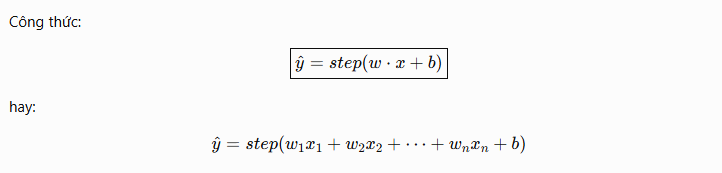  
step đó không phải là bước nhảy mà nó là 1 hàm có tên là step  
w thì vẫn là weight và b thì là bias  
- ví dụ:  

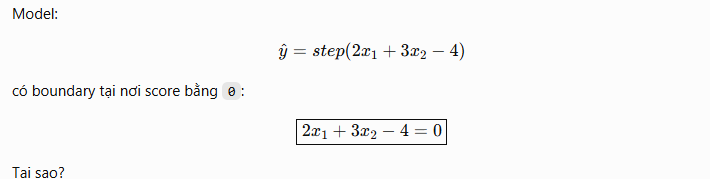  
ta thấy cái hàm số trong đó cái đó gọi là desion boundary  

  
- và sau này công thức trên đã được update thành công thức mới  
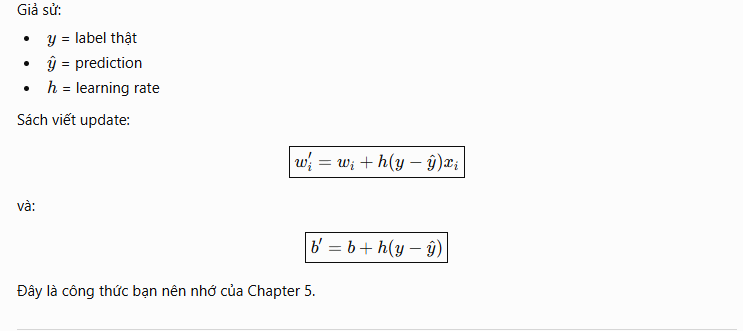  
- trong đó có khái niệm learning rate: đó là cái quyết định 1 lần học nó thay đổi giá trị trong đó là bao nhiêu  
- epcho là số lần cho model học

w1 = -0.009999999999999998, w2 = 0.029999999999999992, b = -0.03
Accuracy: 0.5


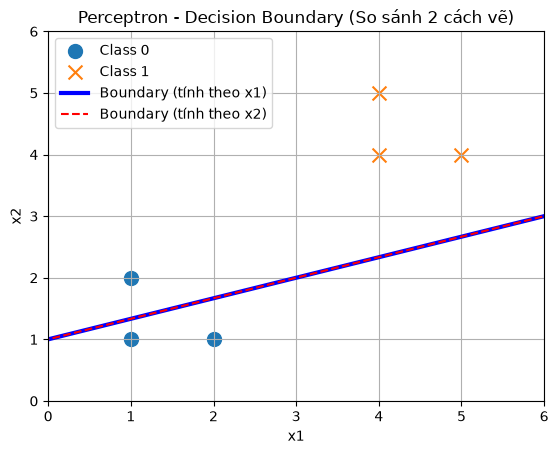

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# ============================================================
# 1. TẠO DATA
# ============================================================
X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [4, 4],
    [4, 5],
    [5, 4]
])

y = np.array([
    0,
    0,
    0,
    1,
    1,
    1
])


# ============================================================
# 2. CHIA TRAIN / TEST
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)


# ============================================================
# 3. TẠO & TRAIN PERCEPTRON
# ============================================================
model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)

model.fit(X_train, y_train)


# ============================================================
# 4. LẤY WEIGHTS VÀ BIAS
# ============================================================
w1, w2 = model.coef_[0]
b = model.intercept_[0]

print(f"w1 = {w1}, w2 = {w2}, b = {b}")


# ============================================================
# 5. PREDICT & EVALUATE
# ============================================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# ============================================================
# 6. VISUALIZE DATA & DECISION BOUNDARIES
# ============================================================

# Vẽ các điểm dữ liệu Class 0 và Class 1
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    marker="o",
    s=100
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    marker="x",
    s=100
)


# --- CÁCH 1: Vẽ x2 theo x1 (Màu xanh dương) ---
if w2 != 0:
    x1_line = np.linspace(0, 6, 100)
    x2_line = -(w1 * x1_line + b) / w2
    
    plt.plot(
        x1_line,
        x2_line,
        color="blue",
        linewidth=3,
        linestyle="-",
        label="Boundary (tính theo x1)"
    )


# --- CÁCH 2: Vẽ x1 theo x2 (Màu đỏ) ---
if w1 != 0:
    x2_line_2 = np.linspace(0, 6, 100)
    x1_line_2 = -(w2 * x2_line_2 + b) / w1
    
    plt.plot(
        x1_line_2,
        x2_line_2,
        color="red",
        linewidth=1.5,
        linestyle="--",  # Dùng nét đứt để dễ phân biệt nếu đè lên nhau
        label="Boundary (tính theo x2)"
    )


# ============================================================
# 7. HOÀN THIỆN BIỂU ĐỒ
# ============================================================
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron - Decision Boundary (So sánh 2 cách vẽ)")
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.grid()
plt.legend()

plt.show()

$$X, y \rightarrow \text{split} \rightarrow \text{model} \rightarrow \text{fit} \rightarrow \text{predict} \rightarrow \text{evaluate}$$

Còn bên trong fit() bạn hiểu rằng Perceptron đang học \(w,b\) để tạo ra decision boundary. Đó là cách nối kiến thức sách với cách làm ML thực tế.

- Sau khi cấu hình (learning_rate, epochs) và gọi .fit():
- Mô hình Perceptron sẽ dò tìm ra các trọng số tốt nhất cho các hệ số $w_1, w_2$ và hệ số tự do $b$
- Hàm của Perceptron: Từ các trọng số đó, ta thu được hàm tính điểm tổng hợp:$$z = w_1 x_1 + w_2 x_2 + b$$Cho bằng 0 để ra đường biên (Decision Boundary): Đặt $z = 0$ tương ứng với ranh giới phân định giữa hai lớp ($0$ và $1$). Khi biểu diễn trên không gian 2D ($x_1, x_2$), phương trình $w_1 x_1 + w_2 x_2 + b = 0$ chính là đường thẳng phân chia mà chúng ta đã dùng np.linspace và lệnh vẽ để hiển thị lên màn hình.